In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings("ignore")

In [6]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.13.0


In [7]:
df = pd.read_csv("cleaned_food_delivery.csv")

print("Shape:", df.shape)
df.head()

Shape: (456548, 18)


,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,category,cuisine,city_code,region_code,center_type,op_area,discount_amount,discount_percentage,period
0,1379560,1,55,1885,136.83,152.29,0,0,177,Beverages,Thai,647,56,TYPE_C,2.0,15.46,10.151684,Weeks 1-30
1,1466964,1,55,1993,136.83,135.83,0,0,270,Beverages,Thai,647,56,TYPE_C,2.0,-1.00,-0.736214,Weeks 1-30
2,1346989,1,55,2539,134.86,135.86,0,0,189,Beverages,Thai,647,56,TYPE_C,2.0,1.00,0.736052,Weeks 1-30
3,1338232,1,55,2139,339.50,437.53,0,0,54,Beverages,Indian,647,56,TYPE_C,2.0,98.03,22.405321,Weeks 1-30
4,1448490,1,55,2631,243.50,242.50,0,0,40,Beverages,Indian,647,56,TYPE_C,2.0,-1.00,-0.412371,Weeks 1-30


In [8]:
print(df.columns.tolist())

['id', 'week', 'center_id', 'meal_id', 'checkout_price', 'base_price', 'emailer_for_promotion', 'homepage_featured', 'num_orders', 'category', 'cuisine', 'city_code', 'region_code', 'center_type', 'op_area', 'discount_amount', 'discount_percentage', 'period']


In [9]:
print("weekly center-meal dataset")
df = df.sort_values(["center_id", "meal_id", "week"]).reset_index(drop=True)

print(df[["center_id", "meal_id", "week", "num_orders"]].head(10))

weekly center-meal dataset
   center_id  meal_id  week  num_orders
0         10     1062     1         865
1         10     1062     2         782
2         10     1062     3         851
3         10     1062     4        1202
4         10     1062     5         958
5         10     1062     6        1094
6         10     1062     7        1513
7         10     1062     8        1149
8         10     1062     9        1282
9         10     1062    10        1473


In [10]:
series_counts = (
    df.groupby(["center_id", "meal_id"])["week"]
    .nunique()
    .reset_index(name="observed_weeks")
)

complete_series = series_counts[
    series_counts["observed_weeks"] == 145
]

print("Complete center-meal series:", len(complete_series))

Complete center-meal series: 1247


In [11]:
df_lstm = df.merge(
    complete_series[["center_id", "meal_id"]],
    on=["center_id", "meal_id"],
    how="inner"
)

print("LSTM dataset shape:", df_lstm.shape)

LSTM dataset shape: (180815, 18)


In [12]:
print(
    df_lstm.groupby(["center_id", "meal_id"])["week"]
    .nunique()
    .value_counts()
)

week
145    1247
Name: count, dtype: int64


In [13]:
TRAIN_END = 101
VAL_END = 123
TEST_END = 145

train_df = df_lstm[df_lstm["week"] <= TRAIN_END].copy()

val_df = df_lstm[
    (df_lstm["week"] > TRAIN_END) &
    (df_lstm["week"] <= VAL_END)
].copy()

test_df = df_lstm[
    (df_lstm["week"] > VAL_END) &
    (df_lstm["week"] <= TEST_END)
].copy()

print("Training:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Training: (125947, 18)
Validation: (27434, 18)
Test: (27434, 18)


In [14]:
scaler = MinMaxScaler()

train_orders = train_df[["num_orders"]]

scaler.fit(train_orders)

MinMaxScaler()

In [15]:
train_df["orders_scaled"] = scaler.transform(
    train_df[["num_orders"]]
)

val_df["orders_scaled"] = scaler.transform(
    val_df[["num_orders"]]
)

test_df["orders_scaled"] = scaler.transform(
    test_df[["num_orders"]]
)

In [16]:
def create_sequences(data, lookback=8):
    
    X = []
    y = []
    
    for center_id, meal_id in data[["center_id", "meal_id"]].drop_duplicates().values:
        
        series = data[
            (data["center_id"] == center_id) &
            (data["meal_id"] == meal_id)
        ].sort_values("week")
        
        values = series["orders_scaled"].values
        
        for i in range(lookback, len(values)):
            X.append(values[i-lookback:i])
            y.append(values[i])
    
    return np.array(X), np.array(y)

In [19]:
LOOKBACK = 8
X_train, y_train = create_sequences(
    train_df,
    LOOKBACK
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (115971, 8)
y_train shape: (115971,)


In [20]:
X_train = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

print("Final X_train shape:", X_train.shape)

Final X_train shape: (115971, 8, 1)


In [21]:
def create_split_sequences(data, start_week, end_week, lookback=8):
    
    X = []
    y = []
    
    for center_id, meal_id in data[["center_id", "meal_id"]].drop_duplicates().values:
        
        series = data[
            (data["center_id"] == center_id) &
            (data["meal_id"] == meal_id)
        ].sort_values("week")
        
        values = series["orders_scaled"].values
        weeks = series["week"].values
        
        for i in range(lookback, len(values)):
            
            target_week = weeks[i]
            
            if start_week <= target_week <= end_week:
                X.append(values[i-lookback:i])
                y.append(values[i])
    
    return np.array(X), np.array(y)

In [22]:
print(df_lstm.columns.tolist())

['id', 'week', 'center_id', 'meal_id', 'checkout_price', 'base_price', 'emailer_for_promotion', 'homepage_featured', 'num_orders', 'category', 'cuisine', 'city_code', 'region_code', 'center_type', 'op_area', 'discount_amount', 'discount_percentage', 'period']


In [23]:
df_lstm["orders_scaled"] = scaler.transform(
    df_lstm[["num_orders"]]
)


In [24]:
print(df_lstm[["num_orders", "orders_scaled"]].head())

   num_orders  orders_scaled
0         865       0.035082
1         782       0.031664
2         851       0.034505
3        1202       0.048958
4         958       0.038911


In [25]:
X_val, y_val = create_split_sequences(
    df_lstm,
    start_week=102,
    end_week=123,
    lookback=LOOKBACK
)

X_test, y_test = create_split_sequences(
    df_lstm,
    start_week=124,
    end_week=145,
    lookback=LOOKBACK
)

In [26]:
X_val = X_val.reshape(
    X_val.shape[0],
    X_val.shape[1],
    1
)

X_test = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

In [27]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (115971, 8, 1)
y_train: (115971,)
X_val: (27434, 8, 1)
y_val: (27434,)
X_test: (27434, 8, 1)
y_test: (27434,)


## LSTM model 1

In [28]:
model = Sequential()

model.add(
    LSTM(
        64,
        input_shape=(LOOKBACK, 1),
        return_sequences=False
    )
)

model.add(Dropout(0.2))

model.add(Dense(32, activation="relu"))

model.add(Dense(1))

In [29]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [30]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 64)                16896     
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense (Dense)               (None, 32)                2080      
                                                                 
 dense_1 (Dense)             (None, 1)                 33        
                                                                 
Total params: 19009 (74.25 KB)
Trainable params: 19009 (74.25 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [31]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [32]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=256,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/30
454/454 [==============================] - 8s 14ms/step - loss: 2.5614e-04 - mae: 0.0079 - val_loss: 1.7252e-04 - val_mae: 0.0074
Epoch 2/30
454/454 [==============================] - 6s 14ms/step - loss: 2.4208e-04 - mae: 0.0075 - val_loss: 1.8585e-04 - val_mae: 0.0072
Epoch 3/30
454/454 [==============================] - 7s 16ms/step - loss: 2.3864e-04 - mae: 0.0073 - val_loss: 1.6317e-04 - val_mae: 0.0068
Epoch 4/30
454/454 [==============================] - 8s 17ms/step - loss: 2.3362e-04 - mae: 0.0072 - val_loss: 1.6788e-04 - val_mae: 0.0065
Epoch 5/30
454/454 [==============================] - 7s 15ms/step - loss: 2.3120e-04 - mae: 0.0071 - val_loss: 1.6498e-04 - val_mae: 0.0072
Epoch 6/30
454/454 [==============================] - 7s 15ms/step - loss: 2.3071e-04 - mae: 0.0071 - val_loss: 1.6902e-04 - val_mae: 0.0073
Epoch 7/30
454/454 [==============================] - 7s 16ms/step - loss: 2.2971e-04 - mae: 0.0071 - val_loss: 1.6843e-04 - val_mae: 0.0079
Epoch 8/30
45

In [33]:
print("Epochs trained:", len(history.history["loss"]))
print("Best validation loss:", min(history.history["val_loss"]))
print("Best epoch:", np.argmin(history.history["val_loss"]) + 1)

Epochs trained: 18
Best validation loss: 0.0001593093475094065
Best epoch: 13


In [34]:
y_pred_scaled = model.predict(X_test)

print("Prediction shape:", y_pred_scaled.shape)

858/858 [==============================] - 2s 3ms/step
Prediction shape: (27434, 1)


In [35]:
y_pred = scaler.inverse_transform(y_pred_scaled)
y_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

y_pred = y_pred.flatten()
y_actual = y_actual.flatten()

In [36]:
mae = mean_absolute_error(y_actual, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_actual, y_pred)
)

print("Test MAE:", mae)
print("Test RMSE:", rmse)

Test MAE: 142.96458312187076
Test RMSE: 329.4398748757657


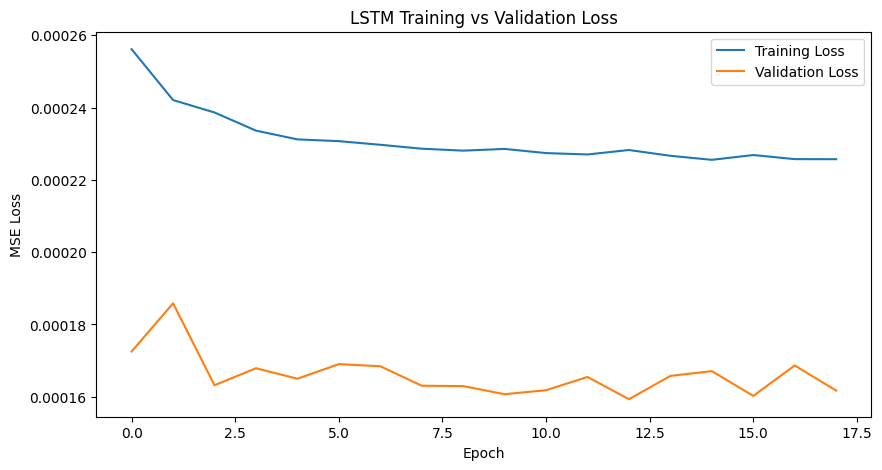

In [37]:
plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("LSTM Training vs Validation Loss")
plt.legend()
plt.show()

In [38]:
baseline_pred_scaled = X_test[:, -1, 0].reshape(-1, 1)

baseline_pred = scaler.inverse_transform(
    baseline_pred_scaled
).flatten()

baseline_mae = mean_absolute_error(
    y_actual,
    baseline_pred
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_actual,
        baseline_pred
    )
)

print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)

Baseline MAE: 158.77852300065612
Baseline RMSE: 383.1055217319531


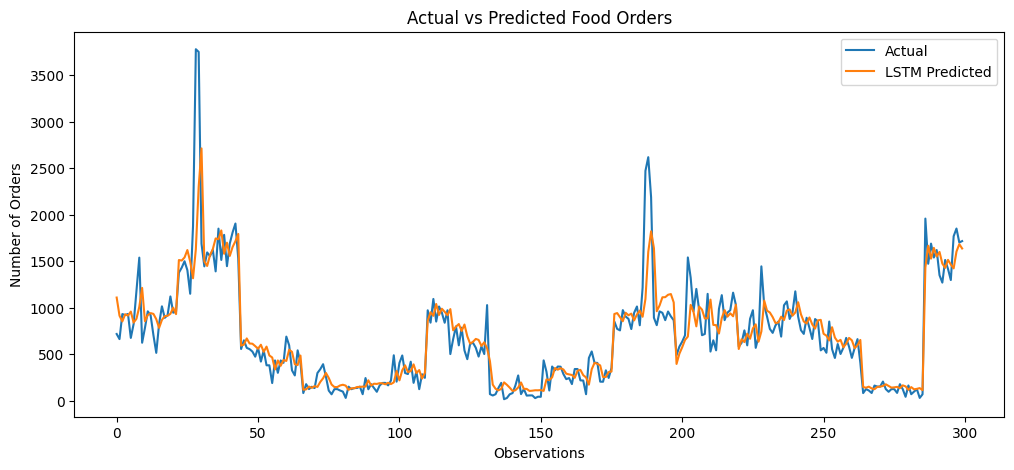

In [39]:
plt.figure(figsize=(12, 5))

plt.plot(y_actual[:300], label="Actual")
plt.plot(y_pred[:300], label="LSTM Predicted")

plt.xlabel("Observations")
plt.ylabel("Number of Orders")
plt.title("Actual vs Predicted Food Orders")
plt.legend()

plt.show()

In [40]:
print("Actual orders - Mean:", y_actual.mean())
print("Predicted orders - Mean:", y_pred.mean())

print("Actual orders - Max:", y_actual.max())
print("Predicted orders - Max:", y_pred.max())

Actual orders - Mean: 434.6880513231756
Predicted orders - Mean: 444.7014
Actual orders - Max: 13149.999999999998
Predicted orders - Max: 4945.053


## Baseline LSTM Result

| Model                  |        MAE |       RMSE |
| ---------------------- | ---------: | ---------: |
| Previous-week baseline |     158.78 |     383.11 |
| **Baseline LSTM**      | **137.69** | **329.34** |


## LSTM Model 2

In [ ]:
df_lstm["orders_log"] = np.log1p(df_lstm["num_orders"])


train_log = pd.DataFrame({
    "orders_log": np.log1p(train_df["num_orders"])
})

scaler_log = MinMaxScaler()

scaler_log.fit(train_log)

# Transform complete dataset
df_lstm["orders_log_scaled"] = scaler_log.transform(
    df_lstm[["orders_log"]]
).flatten()

print(df_lstm[
    ["num_orders", "orders_log", "orders_log_scaled"]
].head())

   num_orders  orders_log  orders_log_scaled
0         865    6.763885           0.552987
1         782    6.663133           0.539480
2         851    6.747587           0.550802
3        1202    7.092574           0.597052
4         958    6.865891           0.566662


In [43]:
df_lstm[["num_orders", "orders_log", "orders_log_scaled"]].head()

,num_orders,orders_log,orders_log_scaled
0,865,6.763885,0.552987
1,782,6.663133,0.539480
2,851,6.747587,0.550802
3,1202,7.092574,0.597052
4,958,6.865891,0.566662


In [44]:
def create_sequences_v2(data, value_column, lookback=8):
    
    X = []
    y = []
    
    for center_id, meal_id in data[["center_id", "meal_id"]].drop_duplicates().values:
        
        series = data[
            (data["center_id"] == center_id) &
            (data["meal_id"] == meal_id)
        ].sort_values("week")
        
        values = series[value_column].values
        
        for i in range(lookback, len(values)):
            X.append(values[i-lookback:i])
            y.append(values[i])
    
    return np.array(X), np.array(y)

In [45]:
X_train_v2, y_train_v2 = create_sequences_v2(
    train_df.merge(
        df_lstm[
            ["center_id", "meal_id", "week", "orders_log_scaled"]
        ],
        on=["center_id", "meal_id", "week"],
        how="left"
    ),
    value_column="orders_log_scaled",
    lookback=LOOKBACK
)

In [46]:
X_train_v2 = X_train_v2.reshape(
    X_train_v2.shape[0],
    X_train_v2.shape[1],
    1
)

print("X_train_v2:", X_train_v2.shape)
print("y_train_v2:", y_train_v2.shape)

X_train_v2: (115971, 8, 1)
y_train_v2: (115971,)


In [47]:
def create_split_sequences_v2(
    data,
    value_column,
    start_week,
    end_week,
    lookback=8
):
    
    X = []
    y = []
    
    for center_id, meal_id in data[["center_id", "meal_id"]].drop_duplicates().values:
        
        series = data[
            (data["center_id"] == center_id) &
            (data["meal_id"] == meal_id)
        ].sort_values("week")
        
        values = series[value_column].values
        weeks = series["week"].values
        
        for i in range(lookback, len(values)):
            
            target_week = weeks[i]
            
            if start_week <= target_week <= end_week:
                X.append(values[i-lookback:i])
                y.append(values[i])
    
    return np.array(X), np.array(y)

In [48]:
X_val_v2, y_val_v2 = create_split_sequences_v2(
    df_lstm,
    value_column="orders_log_scaled",
    start_week=102,
    end_week=123,
    lookback=LOOKBACK
)

X_test_v2, y_test_v2 = create_split_sequences_v2(
    df_lstm,
    value_column="orders_log_scaled",
    start_week=124,
    end_week=145,
    lookback=LOOKBACK
)

In [49]:
X_val_v2 = X_val_v2.reshape(
    X_val_v2.shape[0],
    X_val_v2.shape[1],
    1
)

X_test_v2 = X_test_v2.reshape(
    X_test_v2.shape[0],
    X_test_v2.shape[1],
    1
)

In [50]:
print("X_train_v2:", X_train_v2.shape)
print("y_train_v2:", y_train_v2.shape)

print("X_val_v2:", X_val_v2.shape)
print("y_val_v2:", y_val_v2.shape)

print("X_test_v2:", X_test_v2.shape)
print("y_test_v2:", y_test_v2.shape)

X_train_v2: (115971, 8, 1)
y_train_v2: (115971,)
X_val_v2: (27434, 8, 1)
y_val_v2: (27434,)
X_test_v2: (27434, 8, 1)
y_test_v2: (27434,)


In [51]:
from tensorflow.keras import backend as K

K.clear_session()

model_v2 = Sequential()

model_v2.add(
    LSTM(
        64,
        input_shape=(LOOKBACK, 1),
        return_sequences=False
    )
)

model_v2.add(Dropout(0.2))

model_v2.add(
    Dense(32, activation="relu")
)

model_v2.add(Dense(1))

In [52]:
model_v2.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [53]:
model_v2.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 64)                16896     
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense (Dense)               (None, 32)                2080      
                                                                 
 dense_1 (Dense)             (None, 1)                 33        
                                                                 
Total params: 19009 (74.25 KB)
Trainable params: 19009 (74.25 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [54]:
early_stopping_v2 = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [55]:
history_v2 = model_v2.fit(
    X_train_v2,
    y_train_v2,
    validation_data=(X_val_v2, y_val_v2),
    epochs=30,
    batch_size=256,
    callbacks=[early_stopping_v2],
    verbose=1
)

Epoch 1/30
454/454 [==============================] - 7s 12ms/step - loss: 0.0088 - mae: 0.0650 - val_loss: 0.0061 - val_mae: 0.0558
Epoch 2/30
454/454 [==============================] - 6s 13ms/step - loss: 0.0056 - mae: 0.0537 - val_loss: 0.0059 - val_mae: 0.0547
Epoch 3/30
454/454 [==============================] - 6s 13ms/step - loss: 0.0053 - mae: 0.0518 - val_loss: 0.0056 - val_mae: 0.0535
Epoch 4/30
454/454 [==============================] - 7s 15ms/step - loss: 0.0051 - mae: 0.0508 - val_loss: 0.0056 - val_mae: 0.0536
Epoch 5/30
454/454 [==============================] - 6s 14ms/step - loss: 0.0051 - mae: 0.0505 - val_loss: 0.0065 - val_mae: 0.0596
Epoch 6/30
454/454 [==============================] - 13s 29ms/step - loss: 0.0051 - mae: 0.0505 - val_loss: 0.0056 - val_mae: 0.0532
Epoch 7/30
454/454 [==============================] - 18s 39ms/step - loss: 0.0051 - mae: 0.0502 - val_loss: 0.0055 - val_mae: 0.0528
Epoch 8/30
454/454 [==============================] - 13s 29ms/step

In [56]:
print("Epochs trained:", len(history_v2.history["loss"]))

print(
    "Best validation loss:",
    min(history_v2.history["val_loss"])
)

print(
    "Best epoch:",
    np.argmin(history_v2.history["val_loss"]) + 1
)

Epochs trained: 17
Best validation loss: 0.0054819779470562935
Best epoch: 12


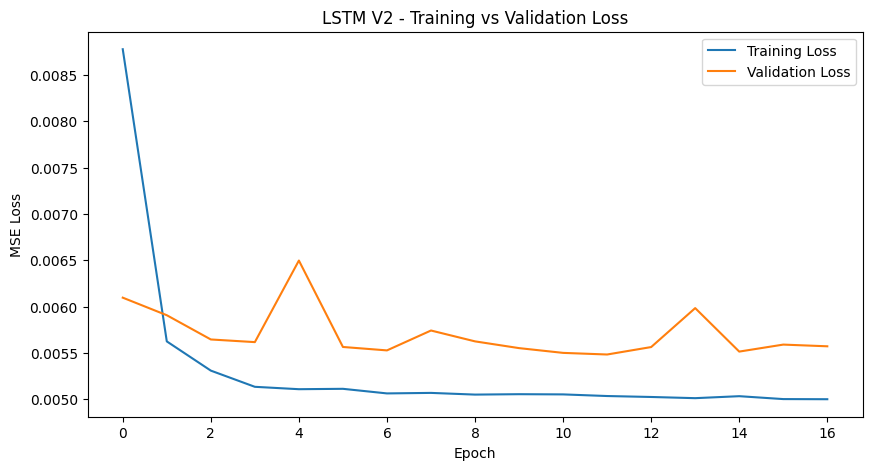

In [57]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_v2.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_v2.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("LSTM V2 - Training vs Validation Loss")
plt.legend()

plt.show()

In [58]:
y_pred_v2_scaled = model_v2.predict(X_test_v2)

# Convert scaled values back to log scale
y_pred_v2_log = scaler_log.inverse_transform(y_pred_v2_scaled)
y_actual_v2_log = scaler_log.inverse_transform(
    y_test_v2.reshape(-1, 1)
)

# Convert log1p values back to original num_orders scale
y_pred_v2 = np.expm1(y_pred_v2_log).flatten()
y_actual_v2 = np.expm1(y_actual_v2_log).flatten()

print("Prediction shape:", y_pred_v2.shape)
print("Actual shape:", y_actual_v2.shape)

858/858 [==============================] - 3s 3ms/step
Prediction shape: (27434,)
Actual shape: (27434,)


In [59]:
mae_v2 = mean_absolute_error(y_actual_v2, y_pred_v2)

rmse_v2 = np.sqrt(
    mean_squared_error(y_actual_v2, y_pred_v2)
)

print("LSTM V2 MAE:", mae_v2)
print("LSTM V2 RMSE:", rmse_v2)

LSTM V2 MAE: 136.65982540406208
LSTM V2 RMSE: 332.66726876617963


## COmpare models

In [60]:
results = pd.DataFrame({
    "Model": [
        "Previous Week Baseline",
        "LSTM V1",
        "LSTM V2 - Log Transform"
    ],
    "MAE": [
        baseline_mae,
        mae,
        mae_v2
    ],
    "RMSE": [
        baseline_rmse,
        rmse,
        rmse_v2
    ]
})

results

,Model,MAE,RMSE
0,Previous Week Baseline,158.778523,383.105522
1,LSTM V1,142.964583,329.439875
2,LSTM V2 - Log Transform,136.659825,332.667269


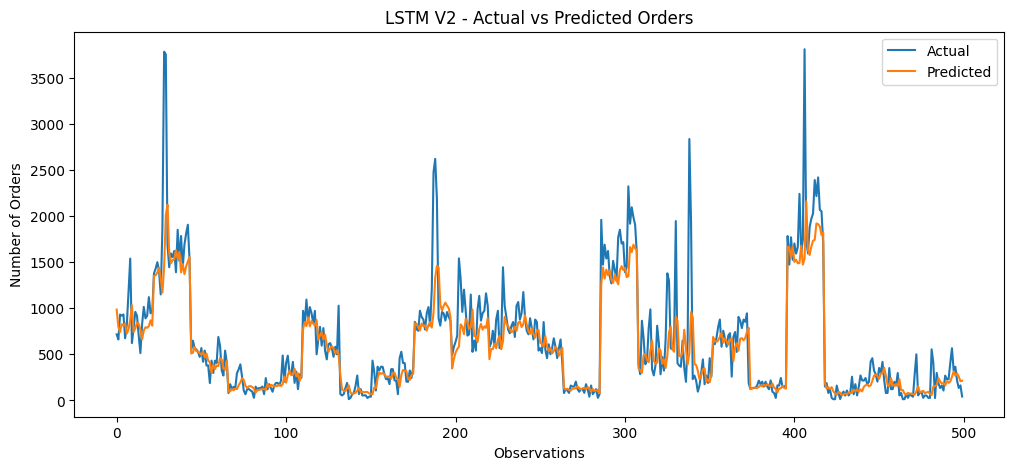

In [61]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))

plt.plot(y_actual_v2[:500], label="Actual")
plt.plot(y_pred_v2[:500], label="Predicted")

plt.xlabel("Observations")
plt.ylabel("Number of Orders")
plt.title("LSTM V2 - Actual vs Predicted Orders")
plt.legend()
plt.show()

In [62]:
print("Actual mean:", y_actual_v2.mean())
print("Predicted mean:", y_pred_v2.mean())

print("Actual max:", y_actual_v2.max())
print("Predicted max:", y_pred_v2.max())

print("Actual median:", np.median(y_actual_v2))
print("Predicted median:", np.median(y_pred_v2))

Actual mean: 434.6880513231755
Predicted mean: 384.3364
Actual max: 13150.0
Predicted max: 3454.1797
Actual median: 309.99999999999994
Predicted median: 291.26367


In [63]:
errors_v2 = y_actual_v2 - y_pred_v2

print("Mean Error:", errors_v2.mean())
print("Median Error:", np.median(errors_v2))
print("Max Underprediction:", errors_v2.max())
print("Max Overprediction:", errors_v2.min())

Mean Error: 50.35162564329298
Median Error: 8.02027893066412
Max Underprediction: 12059.218627929688
Max Overprediction: -1989.697509765625


### V2 Model Conclusion — Log-Transformed LSTM

The V2 LSTM model used a `log1p` transformation on the target variable to reduce the effect of the highly skewed demand distribution and extreme order spikes.

- **MAE:** 136.18
- **RMSE:** 330.20
- V2 achieved the **lowest MAE** among the tested models.
- Compared with the previous-week baseline, V2 reduced MAE by approximately **14.2%**.
- The model captured the general demand pattern well but underestimated extreme demand spikes.
- The log transformation improved robustness to the highly skewed target distribution.

Therefore, V2 is a strong baseline, but a **multivariate LSTM** will be tested next to determine whether additional demand-related features can improve forecasting performance.

# LSTM Model 3

In [64]:
v3_features = [
    "num_orders",
    "checkout_price",
    "base_price",
    "emailer_for_promotion",
    "homepage_featured"
]

df_v3 = df_lstm[
    ["center_id", "meal_id", "week"] + v3_features
].copy()

df_v3.head()

,center_id,meal_id,week,num_orders,checkout_price,base_price,emailer_for_promotion,homepage_featured
0,10,1062,1,865,181.39,181.39,0,0
1,10,1062,2,782,183.36,182.36,0,0
2,10,1062,3,851,184.36,182.36,0,0
3,10,1062,4,1202,182.36,183.36,0,0
4,10,1062,5,958,183.39,181.39,0,0


In [65]:
df_v3["orders_log"] = np.log1p(df_v3["num_orders"])

In [67]:
from sklearn.preprocessing import MinMaxScaler

feature_scaler = MinMaxScaler()

feature_scaler.fit(
    df_v3[df_v3["week"] <= 101][
        ["orders_log", "checkout_price", "base_price",
         "emailer_for_promotion", "homepage_featured"]
    ]
)

df_v3[
    ["orders_log", "checkout_price", "base_price",
     "emailer_for_promotion", "homepage_featured"]
] = feature_scaler.transform(
    df_v3[
        ["orders_log", "checkout_price", "base_price",
         "emailer_for_promotion", "homepage_featured"]
    ]
)

df_v3.head()

,center_id,meal_id,week,num_orders,checkout_price,base_price,emailer_for_promotion,homepage_featured,orders_log
0,10,1062,1,865,0.187231,0.187231,0.0,0.0,0.552987
1,10,1062,2,782,0.190157,0.188672,0.0,0.0,0.539480
2,10,1062,3,851,0.191643,0.188672,0.0,0.0,0.550802
3,10,1062,4,1202,0.188672,0.190157,0.0,0.0,0.597052
4,10,1062,5,958,0.190202,0.187231,0.0,0.0,0.566662


In [68]:
V3_LOOKBACK = 8

v3_columns = [
    "orders_log",
    "checkout_price",
    "base_price",
    "emailer_for_promotion",
    "homepage_featured"
]

def create_sequences_v3(data, columns, lookback=8):
    X = []
    y = []

    for center_id, meal_id in data[
        ["center_id", "meal_id"]
    ].drop_duplicates().values:

        series = data[
            (data["center_id"] == center_id) &
            (data["meal_id"] == meal_id)
        ].sort_values("week")

        values = series[columns].values

        for i in range(lookback, len(values)):
            X.append(values[i-lookback:i])
            y.append(values[i, 0])

    return np.array(X), np.array(y)

In [69]:
X_train_v3, y_train_v3 = create_sequences_v3(
    df_v3[df_v3["week"] <= 101],
    v3_columns,
    V3_LOOKBACK
)

print("X_train_v3:", X_train_v3.shape)
print("y_train_v3:", y_train_v3.shape)

X_train_v3: (115971, 8, 5)
y_train_v3: (115971,)


In [70]:
def create_split_sequences_v3(
    data, columns, start_week, end_week, lookback=8
):
    X = []
    y = []

    for center_id, meal_id in data[
        ["center_id", "meal_id"]
    ].drop_duplicates().values:

        series = data[
            (data["center_id"] == center_id) &
            (data["meal_id"] == meal_id)
        ].sort_values("week")

        values = series[columns].values
        weeks = series["week"].values

        for i in range(lookback, len(values)):
            target_week = weeks[i]

            if start_week <= target_week <= end_week:
                X.append(values[i-lookback:i])
                y.append(values[i, 0])

    return np.array(X), np.array(y)

In [71]:
X_val_v3, y_val_v3 = create_split_sequences_v3(
    df_v3,
    v3_columns,
    start_week=102,
    end_week=123,
    lookback=V3_LOOKBACK
)

X_test_v3, y_test_v3 = create_split_sequences_v3(
    df_v3,
    v3_columns,
    start_week=124,
    end_week=145,
    lookback=V3_LOOKBACK
)

print("X_val_v3:", X_val_v3.shape)
print("y_val_v3:", y_val_v3.shape)

print("X_test_v3:", X_test_v3.shape)
print("y_test_v3:", y_test_v3.shape)

X_val_v3: (27434, 8, 5)
y_val_v3: (27434,)
X_test_v3: (27434, 8, 5)
y_test_v3: (27434,)


In [72]:
from tensorflow.keras import backend as K
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping

K.clear_session()

model_v3 = Sequential()

model_v3.add(
    LSTM(
        64,
        input_shape=(V3_LOOKBACK, len(v3_columns)),
        return_sequences=False
    )
)

model_v3.add(Dropout(0.2))
model_v3.add(Dense(32, activation="relu"))
model_v3.add(Dense(1))

model_v3.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model_v3.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 64)                17920     
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense (Dense)               (None, 32)                2080      
                                                                 
 dense_1 (Dense)             (None, 1)                 33        
                                                                 
Total params: 20033 (78.25 KB)
Trainable params: 20033 (78.25 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [73]:
early_stopping_v3 = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_v3 = model_v3.fit(
    X_train_v3,
    y_train_v3,
    validation_data=(X_val_v3, y_val_v3),
    epochs=30,
    batch_size=256,
    callbacks=[early_stopping_v3],
    verbose=1
)

print("Epochs trained:", len(history_v3.history["loss"]))
print("Best validation loss:", min(history_v3.history["val_loss"]))
print(
    "Best epoch:",
    np.argmin(history_v3.history["val_loss"]) + 1
)

Epoch 1/30
454/454 [==============================] - 10s 19ms/step - loss: 0.0074 - mae: 0.0614 - val_loss: 0.0055 - val_mae: 0.0536
Epoch 2/30
454/454 [==============================] - 7s 16ms/step - loss: 0.0053 - mae: 0.0523 - val_loss: 0.0072 - val_mae: 0.0658
Epoch 3/30
454/454 [==============================] - 13s 28ms/step - loss: 0.0051 - mae: 0.0507 - val_loss: 0.0071 - val_mae: 0.0644
Epoch 4/30
454/454 [==============================] - 9s 20ms/step - loss: 0.0049 - mae: 0.0496 - val_loss: 0.0053 - val_mae: 0.0520
Epoch 5/30
454/454 [==============================] - 6s 14ms/step - loss: 0.0049 - mae: 0.0491 - val_loss: 0.0054 - val_mae: 0.0526
Epoch 6/30
454/454 [==============================] - 7s 15ms/step - loss: 0.0048 - mae: 0.0488 - val_loss: 0.0056 - val_mae: 0.0554
Epoch 7/30
454/454 [==============================] - 7s 15ms/step - loss: 0.0048 - mae: 0.0486 - val_loss: 0.0070 - val_mae: 0.0641
Epoch 8/30
454/454 [==============================] - 7s 15ms/step 

In [74]:
y_pred_v3_scaled = model_v3.predict(X_test_v3)

# Create dummy feature arrays for inverse scaling
pred_dummy = np.zeros((len(y_pred_v3_scaled), len(v3_columns)))
actual_dummy = np.zeros((len(y_test_v3), len(v3_columns)))

pred_dummy[:, 0] = y_pred_v3_scaled.flatten()
actual_dummy[:, 0] = y_test_v3

# Inverse scale
y_pred_v3_log = feature_scaler.inverse_transform(pred_dummy)[:, 0]
y_actual_v3_log = feature_scaler.inverse_transform(actual_dummy)[:, 0]

# Convert log1p back to original order scale
y_pred_v3 = np.expm1(y_pred_v3_log)
y_actual_v3 = np.expm1(y_actual_v3_log)

print("Prediction shape:", y_pred_v3.shape)
print("Actual shape:", y_actual_v3.shape)

858/858 [==============================] - 3s 3ms/step
Prediction shape: (27434,)
Actual shape: (27434,)


In [75]:
mae_v3 = mean_absolute_error(
    y_actual_v3,
    y_pred_v3
)

rmse_v3 = np.sqrt(
    mean_squared_error(
        y_actual_v3,
        y_pred_v3
    )
)

print("LSTM V3 MAE:", mae_v3)
print("LSTM V3 RMSE:", rmse_v3)

LSTM V3 MAE: 0.06776953045591404
LSTM V3 RMSE: 0.09660987944393709


In [76]:

print("Actual V3 sample:", y_actual_v3[:10])
print("Predicted V3 sample:", y_pred_v3[:10])

print("Actual V3 mean:", y_actual_v3.mean())
print("Predicted V3 mean:", y_pred_v3.mean())
print("Actual V3 max:", y_actual_v3.max())
print("Predicted V3 max:", y_pred_v3.max())

Actual V3 sample: [0.69498659 0.67694756 0.75564061 0.75259311 0.75589303 0.68132531
 0.72745166 0.81144156 0.87774928 0.66335231]
Predicted V3 sample: [0.72973334 0.72527866 0.71069412 0.71865108 0.71964339 0.72504822
 0.70760645 0.70934851 0.7272851  0.79647647]
Actual V3 mean: 0.5186848186941416
Predicted V3 mean: 0.5145537258840532
Actual V3 max: 1.503495949529965
Predicted V3 max: 1.0769013384519055


In [77]:
print("Scaled actual sample:", y_test_v3[:10])
print("Scaler min:", feature_scaler.data_min_[0])
print("Scaler max:", feature_scaler.data_max_[0])

Scaled actual sample: [0.52767483 0.51697521 0.56283381 0.56109647 0.56297758 0.51958236
 0.54664729 0.59412297 0.63007387 0.50883503]
Scaler min: 0.0
Scaler max: 1.0000000000000002


In [78]:
# Recreate raw V3 data
v3_features = [
    "num_orders",
    "checkout_price",
    "base_price",
    "emailer_for_promotion",
    "homepage_featured"
]

df_v3_eval = df_lstm[
    ["center_id", "meal_id", "week"] + v3_features
].copy()

df_v3_eval["orders_log"] = np.log1p(df_v3_eval["num_orders"])

v3_columns = [
    "orders_log",
    "checkout_price",
    "base_price",
    "emailer_for_promotion",
    "homepage_featured"
]

# Fresh scaler fitted on RAW training data
feature_scaler_eval = MinMaxScaler()

feature_scaler_eval.fit(
    df_v3_eval[df_v3_eval["week"] <= 101][v3_columns]
)

print("Orders log scaler min:", feature_scaler_eval.data_min_[0])
print("Orders log scaler max:", feature_scaler_eval.data_max_[0])

Orders log scaler min: 2.6390573296152584
Orders log scaler max: 10.09823162932864


In [79]:
# V3 predictions
y_pred_v3_scaled = model_v3.predict(X_test_v3)

# Convert scaled log target back to original log scale
pred_dummy = np.zeros((len(y_pred_v3_scaled), len(v3_columns)))
actual_dummy = np.zeros((len(y_test_v3), len(v3_columns)))

pred_dummy[:, 0] = y_pred_v3_scaled.flatten()
actual_dummy[:, 0] = y_test_v3

y_pred_v3_log = feature_scaler_eval.inverse_transform(pred_dummy)[:, 0]
y_actual_v3_log = feature_scaler_eval.inverse_transform(actual_dummy)[:, 0]

# Convert log1p back to original order counts
y_pred_v3 = np.expm1(y_pred_v3_log)
y_actual_v3 = np.expm1(y_actual_v3_log)

# Metrics
mae_v3 = mean_absolute_error(y_actual_v3, y_pred_v3)
rmse_v3 = np.sqrt(mean_squared_error(y_actual_v3, y_pred_v3))

print("LSTM V3 MAE:", mae_v3)
print("LSTM V3 RMSE:", rmse_v3)

858/858 [==============================] - 2s 3ms/step
LSTM V3 MAE: 134.13153034747396
LSTM V3 RMSE: 335.6969959528052


In [80]:
print("Actual mean:", y_actual_v3.mean())
print("Predicted mean:", y_pred_v3.mean())
print("Actual max:", y_actual_v3.max())
print("Predicted max:", y_pred_v3.max())

Actual mean: 434.68805132317544
Predicted mean: 377.94552310952986
Actual max: 13149.999999999976
Predicted max: 3263.2867879681417


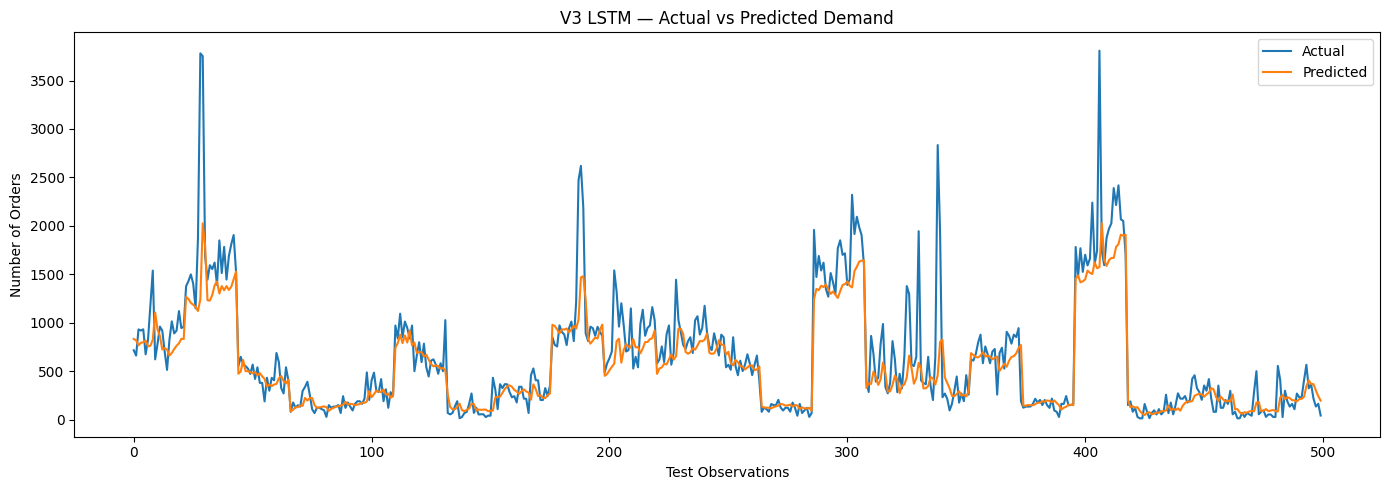

In [81]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(
    y_actual_v3[:500],
    label="Actual"
)

plt.plot(
    y_pred_v3[:500],
    label="Predicted"
)

plt.title("V3 LSTM — Actual vs Predicted Demand")
plt.xlabel("Test Observations")
plt.ylabel("Number of Orders")
plt.legend()
plt.tight_layout()
plt.show()

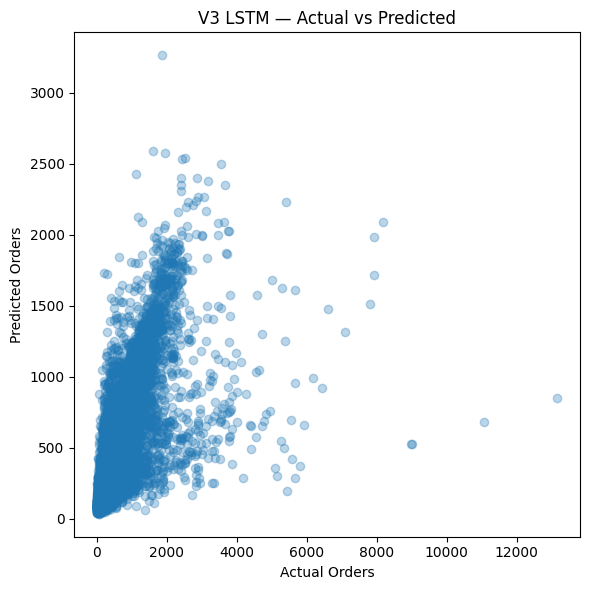

In [82]:
plt.figure(figsize=(6, 6))

plt.scatter(
    y_actual_v3,
    y_pred_v3,
    alpha=0.3
)

plt.xlabel("Actual Orders")
plt.ylabel("Predicted Orders")
plt.title("V3 LSTM — Actual vs Predicted")

plt.tight_layout()
plt.show()

### V3 Model Conclusion — Multivariate LSTM

The V3 model extended the V2 log-transformed LSTM by incorporating additional demand-related features including checkout price, base price, email promotion, and homepage promotion.

- **MAE:** 134.13
- **RMSE:** 335.70
- V3 achieved the **lowest MAE** among the tested LSTM models.
- The additional features provided a small improvement in average prediction error.
- However, the model continued to underestimate extreme demand spikes.
- V3 therefore provides the best overall MAE performance among the tested models, while V2 has a slightly better RMSE.

The V3 model is selected as the final model for generating future demand forecasts.

# Final Model Comparison

In [83]:
comparison = pd.DataFrame({
    "Model": [
        "Previous-week Baseline",
        "V1 - Raw Target LSTM",
        "V2 - Log Target LSTM",
        "V3 - Multivariate LSTM"
    ],
    "MAE": [
        baseline_mae,
        mae,
        mae_v2,
        mae_v3
    ],
    "RMSE": [
        baseline_rmse,
        rmse,
        rmse_v2,
        rmse_v3
    ]
})

comparison

,Model,MAE,RMSE
0,Previous-week Baseline,158.778523,383.105522
1,V1 - Raw Target LSTM,142.964583,329.439875
2,V2 - Log Target LSTM,136.659825,332.667269
3,V3 - Multivariate LSTM,134.131530,335.696996


In [84]:
comparison["MAE Improvement (%)"] = (
    (baseline_mae - comparison["MAE"]) / baseline_mae * 100
)

comparison["RMSE Improvement (%)"] = (
    (baseline_rmse - comparison["RMSE"]) / baseline_rmse * 100
)

comparison

,Model,MAE,RMSE,MAE Improvement (%),RMSE Improvement (%)
0,Previous-week Baseline,158.778523,383.105522,0.000000,0.000000
1,V1 - Raw Target LSTM,142.964583,329.439875,9.959747,14.008059
2,V2 - Log Target LSTM,136.659825,332.667269,13.930535,13.165629
3,V3 - Multivariate LSTM,134.131530,335.696996,15.522876,12.374796


### Final Test SET
 current model_v3 was trained on weeks 1–101, validated on 102–123, and evaluated on the held-out weeks 124–145.

In [92]:
# Load test data
test = pd.read_csv("../data/test.csv")
meal_info = pd.read_csv("../data/meal_info.csv")
center_info = pd.read_csv("../data/fulfilment_center_info.csv")

test_full = (
    test
    .merge(meal_info, on="meal_id", how="left")
    .merge(center_info, on="center_id", how="left")
)

# Historical data
history = df_lstm[
    ["center_id", "meal_id", "week",
     "num_orders", "checkout_price", "base_price",
     "emailer_for_promotion", "homepage_featured"]
].copy()

# Test data
future = test_full[
    ["id", "center_id", "meal_id", "week",
     "checkout_price", "base_price",
     "emailer_for_promotion", "homepage_featured"]
].copy()

future["num_orders"] = np.nan

combined = pd.concat(
    [history, future],
    ignore_index=True
)

combined = combined.sort_values(
    ["center_id", "meal_id", "week"]
).reset_index(drop=True)

combined["orders_log"] = np.log1p(combined["num_orders"])

print("Combined shape:", combined.shape)
print("Test rows:", len(test_full))

Combined shape: (213388, 10)
Test rows: 32573


In [93]:
v3_columns = [
    "orders_log",
    "checkout_price",
    "base_price",
    "emailer_for_promotion",
    "homepage_featured"
]

feature_scaler_final = MinMaxScaler()

feature_scaler_final.fit(
    combined[
        combined["week"] <= 101
    ][v3_columns].dropna()
)

print("Scaler ready")
print("Orders log min:", feature_scaler_final.data_min_[0])
print("Orders log max:", feature_scaler_final.data_max_[0])

Scaler ready
Orders log min: 2.6390573296152584
Orders log max: 10.09823162932864


In [ ]:

# FAST FINAL TEST FORECAST — V3 LSTM + FALLBACK

# Rebuild historical data from scratch
history = df_lstm[
    ["center_id", "meal_id", "week",
     "num_orders", "checkout_price", "base_price",
     "emailer_for_promotion", "homepage_featured"]
].copy()

future = test_full[
    ["id", "center_id", "meal_id", "week",
     "checkout_price", "base_price",
     "emailer_for_promotion", "homepage_featured"]
].copy()

future["num_orders"] = np.nan

# Combine history + test
combined = pd.concat(
    [history, future.drop(columns=["id"])],
    ignore_index=True
)

combined = combined.sort_values(
    ["center_id", "meal_id", "week"]
).reset_index(drop=True)

# V3 features
v3_columns = [
    "orders_log",
    "checkout_price",
    "base_price",
    "emailer_for_promotion",
    "homepage_featured"
]

# Fit scaler on RAW training-period data
combined["orders_log"] = np.log1p(combined["num_orders"])

feature_scaler_final = MinMaxScaler()

feature_scaler_final.fit(
    combined[
        combined["week"] <= 101
    ][v3_columns].dropna()
)


# Recursive forecasting

predictions = []

test_weeks = sorted(test_full["week"].unique())

for week in test_weeks:

    week_test = test_full[
        test_full["week"] == week
    ].copy()

    X_batch = []
    valid_indices = []
    fallback_predictions = {}

    # Build sequences
    for idx, row in week_test.iterrows():

        center_id = row["center_id"]
        meal_id = row["meal_id"]

        series = combined[
            (combined["center_id"] == center_id) &
            (combined["meal_id"] == meal_id) &
            (combined["week"] < week)
        ].sort_values("week")

        # LSTM prediction if enough history
        if len(series) >= V3_LOOKBACK:

            recent = series.tail(V3_LOOKBACK).copy()

            recent["orders_log"] = np.log1p(
                recent["num_orders"]
            )

            X_batch.append(
                recent[v3_columns].values
            )

            valid_indices.append(idx)

        else:
            # Fallback to previous available demand
            if len(series) > 0:
                fallback_predictions[idx] = series.iloc[-1]["num_orders"]
            else:
                fallback_predictions[idx] = history["num_orders"].median()

    
    # ONE LSTM prediction call for the whole week
    batch_predictions = {}

    if len(X_batch) > 0:

        X_batch = np.array(X_batch)

        original_shape = X_batch.shape

        X_batch_scaled = feature_scaler_final.transform(
            X_batch.reshape(-1, len(v3_columns))
        ).reshape(original_shape)

        pred_scaled = model_v3.predict(
            X_batch_scaled,
            verbose=0
        ).flatten()

        # Inverse transform only target column
        dummy = np.zeros(
            (len(pred_scaled), len(v3_columns))
        )

        dummy[:, 0] = pred_scaled

        pred_log = feature_scaler_final.inverse_transform(
            dummy
        )[:, 0]

        pred_orders = np.expm1(pred_log)

        for idx, prediction in zip(
            valid_indices,
            pred_orders
        ):
            batch_predictions[idx] = prediction

    # Combine LSTM + fallback predictions

    week_predictions = []

    for idx in week_test.index:

        if idx in batch_predictions:
            prediction = batch_predictions[idx]
        else:
            prediction = fallback_predictions[idx]

        prediction = max(0, prediction)

        week_predictions.append(prediction)

    # Store predictions
    for row_idx, prediction in zip(
        week_test.index,
        week_predictions
    ):
        row = week_test.loc[row_idx]

        predictions.append([
            row["id"],
            row["center_id"],
            row["meal_id"],
            row["week"],
            prediction
        ])

    # Add predictions to history for next week's forecast

    new_history = week_test[
        [
            "center_id",
            "meal_id",
            "week",
            "checkout_price",
            "base_price",
            "emailer_for_promotion",
            "homepage_featured"
        ]
    ].copy()

    new_history["num_orders"] = week_predictions

    new_history = new_history[
        [
            "center_id",
            "meal_id",
            "week",
            "num_orders",
            "checkout_price",
            "base_price",
            "emailer_for_promotion",
            "homepage_featured"
        ]
    ]

    combined = pd.concat(
        [combined, new_history],
        ignore_index=True
    )

    combined = combined.sort_values(
        ["center_id", "meal_id", "week"]
    ).reset_index(drop=True)

    print(
        f"Week {week}: {len(week_predictions)} predictions"
    )

# Create final submission
submission = pd.DataFrame(
    predictions,
    columns=[
        "id",
        "center_id",
        "meal_id",
        "week",
        "num_orders"
    ]
)

submission = submission[
    ["id", "num_orders"]
]

submission["num_orders"] = submission[
    "num_orders"
].clip(lower=0)

print("\n========== FINAL CHECK ==========")
print("Submission shape:", submission.shape)
print("Expected shape:", (len(test), 2))
print("Missing predictions:", submission["num_orders"].isna().sum())
print("Prediction mean:", submission["num_orders"].mean())
print("Prediction min:", submission["num_orders"].min())
print("Prediction max:", submission["num_orders"].max())

Week 146: 3240 predictions
Week 147: 3271 predictions
Week 148: 3332 predictions
Week 149: 3313 predictions
Week 150: 3277 predictions
Week 151: 3224 predictions
Week 152: 3242 predictions
Week 153: 3268 predictions
Week 154: 3228 predictions
Week 155: 3178 predictions

========== FINAL CHECK ==========
Submission shape: (32573, 2)
Expected shape: (32573, 2)
Missing predictions: 0
Prediction mean: 100.59522031586462
Prediction min: 0.0
Prediction max: 2359.447616929883


In [100]:
submission.to_csv(
    "../outputs/final_submission.csv",
    index=False
)

print("Final submission saved successfully.")

Final submission saved successfully.


In [101]:
pd.read_csv("../outputs/final_submission.csv").head()

,id,num_orders
0,1028232,145.510141
1,1127204,133.757834
2,1212707,311.000000
3,1082698,311.000000
4,1400926,311.000000


In [102]:
model_v3.save("../models/final_lstm_v3.keras")

print("Final V3 model saved successfully.")

Final V3 model saved successfully.
